In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder, StandardScaler
import xgboost as xgb
import joblib

df = pd.read_csv("../data/processed/donnees_salaires_developpeurs.csv")

In [2]:
df["LanguageHaveWorkedWith"] = df["LanguageHaveWorkedWith"].str.split(";")
mlb = MultiLabelBinarizer()
langages_encodes = pd.DataFrame(
    mlb.fit_transform(df["LanguageHaveWorkedWith"]),
    columns=mlb.classes_,
    index=df.index
)
top_langages_liste = langages_encodes.sum().sort_values(ascending=False).head(20).index
langages_encodes = langages_encodes[top_langages_liste]

In [3]:
le_country = LabelEncoder()
le_edlevel = LabelEncoder()
df["Country_enc"] = le_country.fit_transform(df["Country"])
df["EdLevel_enc"] = le_edlevel.fit_transform(df["EdLevel"])

In [4]:
df["nb_competences"] = df["LanguageHaveWorkedWith"].apply(len)

In [5]:
X = pd.concat([
    df[["YearsCodePro", "Country_enc", "EdLevel_enc", "nb_competences"]].reset_index(drop=True),
    langages_encodes.reset_index(drop=True)
], axis=1)
y = df["ConvertedCompYearly"].reset_index(drop=True)
print(X.shape, y.shape)

(35086, 24) (35086,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [8]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [9]:
xgb_model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict(X_test)

In [10]:
def evaluer(y_test, pred, nom):
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{nom} — MAE: {mae:.0f} | RMSE: {rmse:.0f} | R²: {r2:.3f}")
    return mae, rmse, r2

resultats = {}
resultats["Linear Regression"] = evaluer(y_test, pred_lr, "Linear Regression")
resultats["Random Forest"] = evaluer(y_test, pred_rf, "Random Forest")
resultats["XGBoost"] = evaluer(y_test, pred_xgb, "XGBoost")

Linear Regression — MAE: 30434 | RMSE: 49911 | R²: 0.221
Random Forest — MAE: 25513 | RMSE: 48567 | R²: 0.262
XGBoost — MAE: 22649 | RMSE: 45163 | R²: 0.362


In [11]:
import tensorflow as tf

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_nn = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])
model_nn.compile(optimizer="adam", loss="mae")
model_nn.fit(X_train_scaled, y_train, epochs=50, batch_size=32, verbose=0, validation_split=0.1)

pred_nn = model_nn.predict(X_test_scaled).flatten()
resultats["TensorFlow (NN)"] = evaluer(y_test, pred_nn, "Réseau de neurones (TensorFlow)")

c:\Users\bough\Desktop\Projet2_Prédiction_du_Salaire_d'un_Développeur_selon_ses_Compétences\venv\Lib\site-packages\keras\src\layers\core\dense.py:102: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Réseau de neurones (TensorFlow) — MAE: 28133 | RMSE: 49502 | R²: 0.233


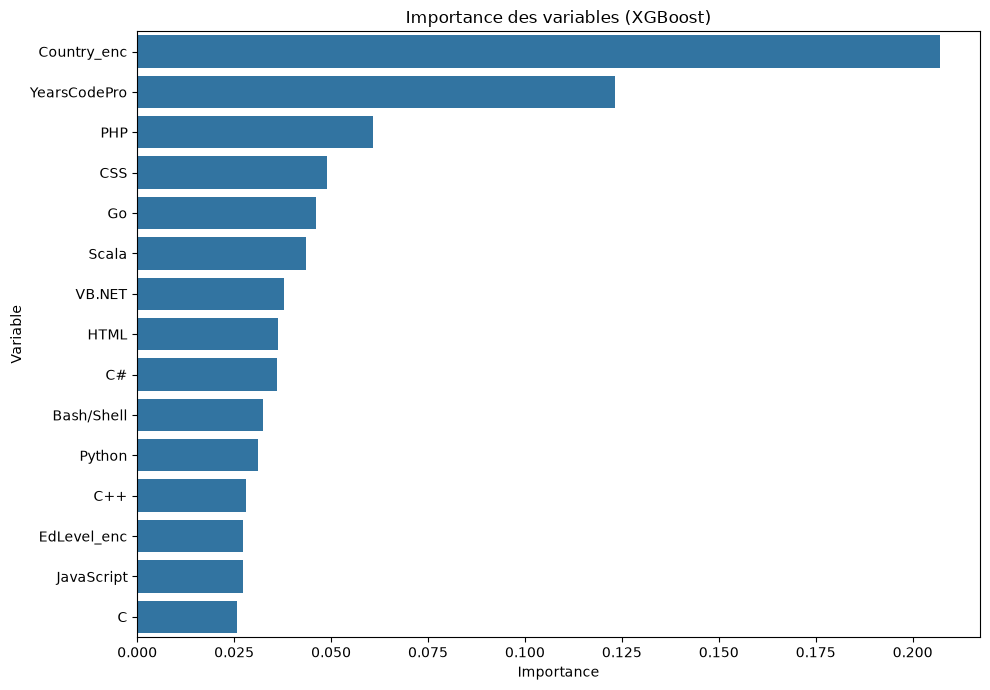

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Importance des variables (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig("../outputs/figures/feature_importance.png", bbox_inches="tight")
plt.show()

In [16]:
joblib.dump(xgb_model, "../models/salary_model.pkl")
joblib.dump(le_country, "../models/le_country.pkl")
joblib.dump(le_edlevel, "../models/le_edlevel.pkl")
joblib.dump(mlb, "../models/mlb_langages.pkl")
joblib.dump(top_langages_liste, "../models/top_langages.pkl")

['../models/top_langages.pkl']

In [18]:
import json

metriques = {
    "Linear Regression": {"mae": resultats["Linear Regression"][0], "rmse": resultats["Linear Regression"][1], "r2": resultats["Linear Regression"][2]},
    "Random Forest": {"mae": resultats["Random Forest"][0], "rmse": resultats["Random Forest"][1], "r2": resultats["Random Forest"][2]},
    "XGBoost": {"mae": resultats["XGBoost"][0], "rmse": resultats["XGBoost"][1], "r2": resultats["XGBoost"][2]},
    "TensorFlow (NN)": {"mae": resultats["TensorFlow (NN)"][0], "rmse": resultats["TensorFlow (NN)"][1], "r2": resultats["TensorFlow (NN)"][2]},
}
with open("../models/metriques.json", "w") as f:
    json.dump(metriques, f)

importance_dict = importances.to_dict()
with open("../models/importance.json", "w") as f:
    json.dump(importance_dict, f)